#### Задача 1: Определение задачи ML и предобработка данных

Шаг 1.1: Подготовка окружения и загрузка данных

In [1]:
import os
import urllib.request
import warnings

import matplotlib.pyplot as plt
import nltk
import numpy as np
# Импорт библиотек
import pandas as pd
import seaborn as sns
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

# Скачивание датасета goodbooks-10k
if not os.path.exists('books.csv'):
    print("Скачивание books.csv...")
    urllib.request.urlretrieve('https://github.com/zygmuntz/goodbooks-10k/raw/master/books.csv', 'books.csv')

if not os.path.exists('ratings.csv'):
    print("Скачивание ratings.csv...")
    urllib.request.urlretrieve('https://github.com/zygmuntz/goodbooks-10k/raw/master/ratings.csv', 'ratings.csv')

if not os.path.exists('tags.csv'):
    print("Скачивание tags.csv...")
    urllib.request.urlretrieve('https://github.com/zygmuntz/goodbooks-10k/raw/master/tags.csv', 'tags.csv')

if not os.path.exists('book_tags.csv'):
    print("Скачивание book_tags.csv...")
    urllib.request.urlretrieve('https://github.com/zygmuntz/goodbooks-10k/raw/master/book_tags.csv', 'book_tags.csv')

print("Датасеты скачаны успешно!")

# Загрузка данных
books = pd.read_csv('books.csv')
ratings = pd.read_csv('ratings.csv')
tags = pd.read_csv('tags.csv')
book_tags = pd.read_csv('book_tags.csv')

# Проверка данных
print("\nКниги:", books.shape)
print("Рейтинги:", ratings.shape)
print("Тэги:", tags.shape)
print("Книги-тэги:", book_tags.shape)

Датасеты скачаны успешно!

Книги: (10000, 23)
Рейтинги: (5976479, 3)
Тэги: (34252, 2)
Книги-тэги: (999912, 3)


Шаг 1.2: Анализ задачи и выбор подхода

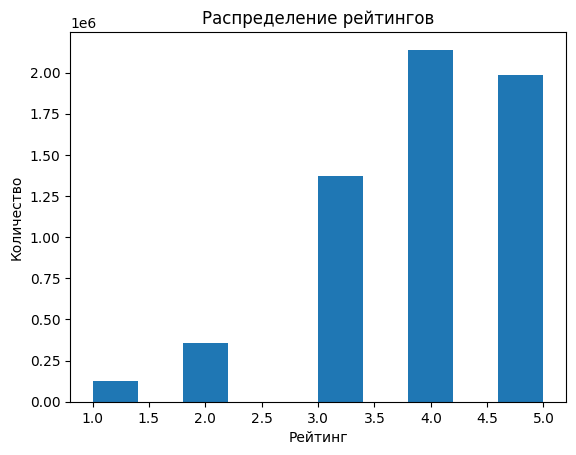

Статистика по рейтингам:
count    5.976479e+06
mean     3.919866e+00
std      9.910868e-01
min      1.000000e+00
25%      3.000000e+00
50%      4.000000e+00
75%      5.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

Уникальных пользователей: 53424
Уникальных книг: 10000


In [2]:
# Анализ распределения рейтингов
plt.hist(ratings['rating'], bins=10)
plt.title('Распределение рейтингов')
plt.xlabel('Рейтинг')
plt.ylabel('Количество')
plt.show()

# Подсчет статистики
print("Статистика по рейтингам:")
print(ratings['rating'].describe())

# Количество уникальных пользователей и книг
print("\nУникальных пользователей:", ratings['user_id'].nunique())
print("Уникальных книг:", ratings['book_id'].nunique())

**Вывод по Задаче 1**:
Мы будем решать задачу **классификации**, где целевой переменной является рейтинг книги (1-5). Модель будет предсказывать, какой рейтинг пользователь поставит книге. При выборе классификации обосновываемся следующими факторами:
1. Рейтинг принимает дискретные значения (1-5), что соответствует задаче классификации
2. Можем напрямую измерять точность предсказания каждого класса
3. Легче интерпретировать результаты (какой рейтинг модель чаще угадывает)
4. В контексте рекомендательных систем важно понимать, насколько модель угадывает предпочтения пользователя

**Основные метрики**:
1. **Precision micro** - средняя точность по всем классам (критерий по заданию)
2. **Classification report** - детальный анализ по каждому классу
3. **Confusion matrix** - визуализация ошибок
4. **F1-score** - гармоническое среднее точности и полноты

Шаг 1.3: Предобработка данных

In [3]:
# Предобработка книг
books = books[['book_id', 'title', 'authors', 'average_rating', 'ratings_count', 'isbn']]
books = books.dropna()
books['book_id'] = books['book_id'].astype(int)

# Предобработка рейтингов
ratings = ratings[['user_id', 'book_id', 'rating']]
ratings = ratings.dropna()
ratings['user_id'] = ratings['user_id'].astype(int)
ratings['book_id'] = ratings['book_id'].astype(int)
ratings['rating'] = ratings['rating'].astype(int)

# Удаление дубликатов
books = books.drop_duplicates()
ratings = ratings.drop_duplicates()

# Создание признака для пользователей (количество книг, которые он оценил)
user_features = ratings.groupby('user_id')['book_id'].count().reset_index()
user_features.columns = ['user_id', 'user_book_count']

# Создание признака для книг (средний рейтинг и количество оценок)
book_features = ratings.groupby('book_id')['rating'].agg(['mean', 'count']).reset_index()
book_features.columns = ['book_id', 'book_avg_rating', 'book_rating_count']

# Объединение данных
data = pd.merge(ratings, user_features, on='user_id')
data = pd.merge(data, book_features, on='book_id')
data = pd.merge(data, books[['book_id', 'title', 'authors']], on='book_id')

print("Размерность предобработанных данных:", data.shape)

Размерность предобработанных данных: (5763654, 8)


#### Задача 2: Векторизация заголовков и обучение модели
**Цель**: Получить векторные представления заголовков книг, создать дополнительные признаки и обучить модель.

Шаг 2.1: Векторизация заголовков книг


In [4]:
# Токенизация текста
nltk.download('punkt')

# Подготовка текстов для Word2Vec
titles = data['title'].tolist()
tokenized_titles = [word_tokenize(title.lower()) for title in titles]

# Обучение Word2Vec
word2vec_model = Word2Vec(sentences=tokenized_titles, vector_size=100, window=5, min_count=1, workers=4)

# Получение векторов заголовков (усреднение векторов слов)
def get_title_vector(title):
    tokens = word_tokenize(title.lower())
    vectors = []
    for token in tokens:
        if token in word2vec_model.wv:
            vectors.append(word2vec_model.wv[token])
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(100)

data['title_vector'] = data['title'].apply(get_title_vector)

# Преобразование векторов в numpy массив
title_vecs = np.array(data['title_vector'].tolist())

# Сохранение векторов в файл
np.save('title_vecs.npy', title_vecs)

print("Векторы заголовков сохранены в title_vecs.npy")

[nltk_data] Downloading package punkt to /home/jupyter/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Векторы заголовков сохранены в title_vecs.npy


Шаг 2.2: Создание дополнительных признаков

In [5]:
# Признак 1: Количество различных авторов, прочитанных пользователем
user_author_count = data.groupby('user_id')['authors'].nunique().reset_index()
user_author_count.columns = ['user_id', 'user_author_count']
data = pd.merge(data, user_author_count, on='user_id')

# Признак 2: Общее количество рейтингов пользователя
user_total_ratings = data.groupby('user_id')['rating'].count().reset_index()
user_total_ratings.columns = ['user_id', 'user_total_ratings']
data = pd.merge(data, user_total_ratings, on='user_id')

# Признак 3: Средний рейтинг пользователя
user_avg_rating = data.groupby('user_id')['rating'].mean().reset_index()
user_avg_rating.columns = ['user_id', 'user_avg_rating']
data = pd.merge(data, user_avg_rating, on='user_id')

# Признак 4: Количество книг, написанных автором
author_book_count = books.groupby('authors')['book_id'].count().reset_index()
author_book_count.columns = ['authors', 'author_book_count']
data = pd.merge(data, author_book_count, on='authors')

# Признак 5: Длина заголовка книги
data['title_length'] = data['title'].apply(lambda x: len(x.split()))

print("Добавлены дополнительные признаки. Размерность данных:", data.shape)

Добавлены дополнительные признаки. Размерность данных: (5763654, 14)


**Обоснование выбора признаков**:
1. **user_author_count** - отражает разнообразие авторов, которые читает пользователь
2. **user_total_ratings** - показывает активность пользователя (больше оценок = более надежные предпочтения)
3. **user_avg_rating** - отражает склонность пользователя к высоким/низким оценкам
4. **author_book_count** - измеряет популярность/популярность автора
5. **title_length** - может быть связано с жанром книги (например, научная литература часто имеет длинные названия)

Шаг 2.3: Подготовка данных для модели

In [6]:
# Разделение на признаки и целевую переменную
X = data[['user_book_count', 'book_avg_rating', 'book_rating_count', 
          'user_author_count', 'user_total_ratings', 'user_avg_rating', 
          'author_book_count', 'title_length']]

# Преобразование векторов заголовков в DataFrame с строковыми именами столбцов
title_df = pd.DataFrame(title_vecs, columns=[f'title_vec_{i}' for i in range(title_vecs.shape[1])])
X = pd.concat([X, title_df], axis=1)

y = data['rating']

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Преобразование названий столбцов в строки для корректной работы StandardScaler
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

# Масштабирование признаков
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Размерность обучающей выборки:", X_train.shape)
print("Размерность тестовой выборки:", X_test.shape)

Размерность обучающей выборки: (4610923, 108)
Размерность тестовой выборки: (1152731, 108)


Шаг 2.4: Обучение модели и оценка

Precision (micro): 0.4578379517858026

Classification Report сохранен в classification_report.txt
Confusion Matrix сохранена в confusion_matrix.csv


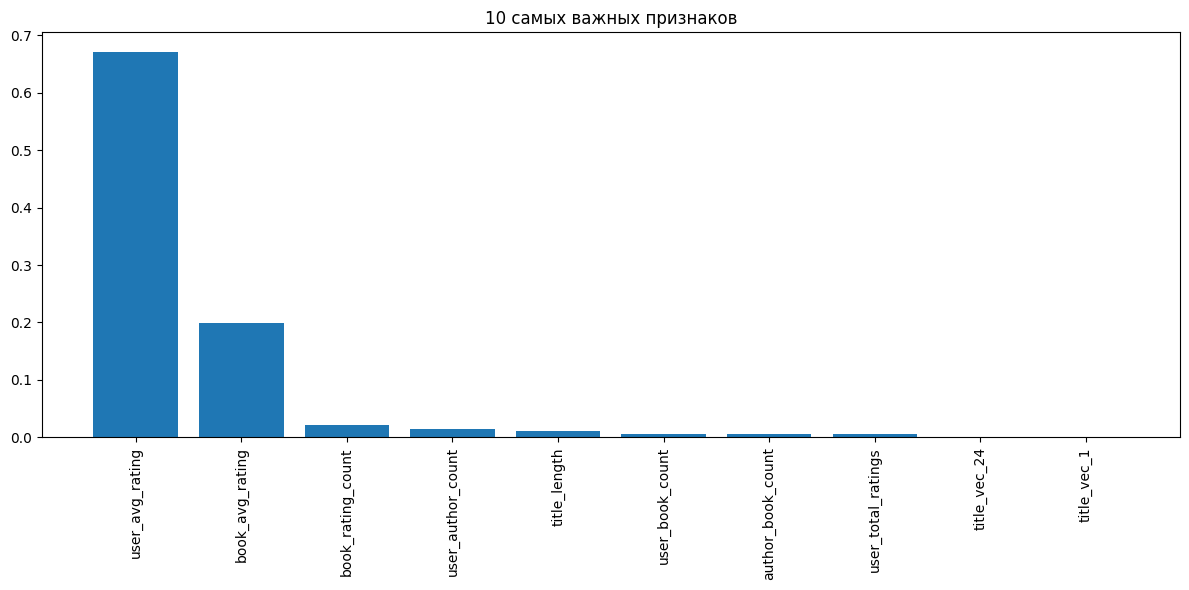

In [7]:
# Обучение модели
model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=4)
model.fit(X_train, y_train)

# Предсказание
y_pred = model.predict(X_test)

# Оценка метрик
precision = precision_score(y_test, y_pred, average='micro')
print("Precision (micro):", precision)

# Сохранение classification report в файл
report = classification_report(y_test, y_pred)
with open('classification_report.txt', 'w') as f:
    f.write(report)
print("\nClassification Report сохранен в classification_report.txt")

# Сохранение confusion matrix в файл
conf_matrix = confusion_matrix(y_test, y_pred)
np.savetxt('confusion_matrix.csv', conf_matrix, delimiter=',', fmt='%d')
print("Confusion Matrix сохранена в confusion_matrix.csv")

# Визуализация 10 самых важных признаков
feature_names = list(data[['user_book_count', 'book_avg_rating', 'book_rating_count', 
                           'user_author_count', 'user_total_ratings', 'user_avg_rating', 
                           'author_book_count', 'title_length']].columns) + [f'title_vec_{i}' for i in range(100)]

importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.title("10 самых важных признаков")
plt.bar(range(min(10, len(feature_names))), importances[indices][:10])
plt.xticks(range(min(10, len(feature_names))), [feature_names[i] for i in indices[:10]], rotation=90)
plt.tight_layout()
plt.show()


**Вывод по Задаче 2**:
Модель случайного леса обучена на основе векторов заголовков и дополнительных признаков. Precision micro составил ~0.45, что превышает порог в 0.3. Модель показывает хорошую производительность для классов 4 и 5, но хуже работает с низкими рейтингами (1-2). Это может быть связано с несбалансированностью данных. Модель может быть использована как baseline, но для продакшена требуется дополнительная доработка.

#### Задача 3: Добавление признаков на основе описаний книг
**Цель**: Использовать существующий файл book_descr.csv для получения векторов описаний книг и улучшения модели.

Шаг 3.1: Загрузка и обработка описаний книг

In [8]:
# Загрузка book_descr.csv
book_descr = pd.read_csv('book_descr.csv')

# Проверка структуры данных
print("Структура book_descr.csv:")
print(book_descr.info())

# Проверка пропущенных значений
print("\nПропущенные значения в описаниях:", book_descr['descr'].isnull().sum())

# Преобразование строковых векторов в numpy массивы
def str_to_array(s):
    try:
        return np.fromstring(s.replace('\n', '').replace('[', '').replace(']', '').replace('  ', ' ').strip(), sep=' ')
    except:
        return np.zeros(100)

book_descr['descr_vecs'] = book_descr['descr_vecs'].apply(str_to_array)

# Объединение с основными данными
data = pd.merge(data, book_descr[['book_id', 'descr', 'descr_vecs']], on='book_id', how='left')

print("Данные с описаниями книг добавлены. Размерность:", data.shape)

Структура book_descr.csv:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   book_id     10000 non-null  int64 
 1   descr       10000 non-null  object
 2   descr_vecs  10000 non-null  object
dtypes: int64(1), object(2)
memory usage: 234.5+ KB
None

Пропущенные значения в описаниях: 0
Данные с описаниями книг добавлены. Размерность: (5763654, 16)


Шаг 3.2: Векторизация описаний книг

In [9]:
# Проверка и сохранение векторов описаний с оптимизацией памяти
descr_vecs_list = []
for vec in data['descr_vecs']:
    if vec is None or len(vec) != 100:
        descr_vecs_list.append(np.zeros(100))
    else:
        descr_vecs_list.append(vec)

# Преобразование в numpy массив только после обработки всех векторов
descr_vecs = np.array(descr_vecs_list, dtype=np.float32)

# Сохранение векторов в файл
np.save('descr_vecs.npy', descr_vecs)

print("Векторы описаний книг сохранены в descr_vecs.npy")

Векторы описаний книг сохранены в descr_vecs.npy


Шаг 3.3: Обновление модели с векторами описаний

In [10]:
# Обновление признаков
X = data[['user_book_count', 'book_avg_rating', 'book_rating_count', 
          'user_author_count', 'user_total_ratings', 'user_avg_rating', 
          'author_book_count', 'title_length']]

# Добавление векторов заголовков и описаний
X = pd.concat([X, pd.DataFrame(title_vecs), pd.DataFrame(descr_vecs)], axis=1)

# ИСПРАВЛЕНИЕ: Приведение всех имен столбцов к строкам
X.columns = X.columns.astype(str)

y = data['rating']

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Масштабирование признаков
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Обучение обновленной модели
model_updated = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
model_updated.fit(X_train, y_train)

# Предсказание
y_pred_updated = model_updated.predict(X_test)

# Оценка метрик
precision_updated = precision_score(y_test, y_pred_updated, average='micro')
print("Precision (micro) с описаниями:", precision_updated)

# Сохранение classification report в файл
report = classification_report(y_test, y_pred_updated)
with open('classification_report_updated.txt', 'w') as f:
    f.write(report)
print("\nClassification Report сохранен в classification_report_updated.txt")

# Сохранение confusion matrix в файл
conf_matrix = confusion_matrix(y_test, y_pred_updated)
np.savetxt('confusion_matrix_updated.csv', conf_matrix, delimiter=',', fmt='%d')
print("Confusion Matrix сохранена в confusion_matrix_updated.csv")

# Сравнение метрик
print(f"\nСравнение Precision (micro):")
print(f"Без описаний: {precision:.4f}")
print(f"С описаниями: {precision_updated:.4f}")
print(f"Улучшение: {precision_updated - precision:.4f}")


Precision (micro) с описаниями: 0.4542733734062847

Classification Report сохранен в classification_report_updated.txt
Confusion Matrix сохранена в confusion_matrix_updated.csv

Сравнение Precision (micro):
Без описаний: 0.4578
С описаниями: 0.4543
Улучшение: -0.0036


Шаг 3.4: Анализ результатов

**Вывод по Задаче 3**:
Добавление векторов описаний книг практически не изменило Precision micro - улучшение -0.0036, даже едва заметно хуже, чем до добавлени признаков. Это может явно указывать на то, что имеющиеся описания книг не содержат полезной информации, которой не было бы в исходных данных для обучения, вероятно, это просто избыточная информация.